# SME Digital Payment Adoption Predictor
## About This Project

In Kenya, millions of small and medium-sized enterprises (SMEs) still rely
on cash for their daily transactions. Yet the infrastructure for digital
payments has never been more accessible

This project uses machine learning to predict which SMEs are most likely to
adopt digital paybill payments, helping financial institutions target the
right businesses with the right interventions at the right time.

### Absa Bank Kenya
Absa Bank Kenya is one of the country's leading commercial banks, currently
investing **KES 3 billion annually** in technology to drive digital banking
adoption. A key part of their digital strategy is growing the number of
businesses and individuals transacting through their paybill number **303030**.

Identifying which SMEs are most likely to go digital is a critical challenge
for their data and analytics teams  and exactly what this model solves.

### Airtel Money Kenya
Airtel Money Kenya recently separated into its own independent entity,
**Airtel Money Kenya Limited**, signaling a serious commitment to becoming
a major player in Kenya's digital payments space.

Through their strategic partnership with Absa Bank Kenya, Airtel Money
customers can now pay directly to Absa paybill 303030 via the **\*334# USSD
menu** or the **My Airtel App**, with incentives including up to **100%
cashback as airtime** on paybill payments.

Understanding which SMEs and individual consumers are ready to embrace this
channel is directly valuable to both organizations.



## Phase 1: Building Our Dataset

### What Are We Doing Here?
Before we can train any machine learning model, we need data to learn from.
Since we don't have access to Absa or Airtel's private customer data,
we build a **realistic synthetic dataset** of 2,000 Kenyan SMEs based on
patterns from the CBK FinAccess Survey and KNBS SME reports.

Think of this phase as creating a practice exam before the real one —
the data is fictional, but the patterns mirror real Kenyan business behaviour.

### What Does Our Dataset Contain?
Each row represents one SME with the following information:

| Feature | What It Means |
|---|---|
| county | Which of Kenya's 47 counties the SME is in |
| sector | Business type e.g. Retail, Food & Beverage, Transport |
| business_age_years | How long the business has been operating |
| monthly_revenue_ksh | Estimated monthly revenue in Kenya Shillings |
| uses_mpesa | Whether the business already uses M-Pesa (1=Yes, 0=No) |
| has_bank_account | Whether the owner has a bank account (1=Yes, 0=No) |
| mobile_money_freq_per_month | How many mobile money transactions per month |
| owns_smartphone | Whether the owner owns a smartphone (1=Yes, 0=No) |
| km_to_nearest_bank | Distance in km to the nearest bank branch |
| num_employees | Number of people working in the business |
| urban | Whether the business is in an urban area (1=Yes, 0=No) |
| will_adopt | **Our target** — will this SME adopt paybill? (1=Yes, 0=No) |

### Why These Features?
These features were chosen because they directly reflect the barriers and
enablers of digital payment adoption in Kenya — the same factors that
Absa Bank Kenya and Airtel Money Kenya's teams think about daily when
designing financial inclusion strategies.

---

In [123]:
# Importing the neccesary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [124]:
np.random.seed(42)
n = 2000

In [125]:
counties = [
    "Nairobi", "Mombasa", "Kisumu", "Nakuru", "Eldoret",
    "Kiambu", "Machakos", "Meru", "Nyeri", "Kakamega",
    "Kisii", "Kilifi", "Garissa", "Kitui", "Bungoma",
    "Uasin Gishu", "Murang'a", "Embu", "Kericho", "Migori"
]

county_weights = [
    0.20, 0.08, 0.07, 0.07, 0.06,
    0.06, 0.05, 0.04, 0.04, 0.04,
    0.04, 0.03, 0.03, 0.03, 0.03,
    0.03, 0.03, 0.02, 0.02, 0.02
]
county_weights = [w / sum(county_weights) for w in county_weights]

sectors = ["Retail", "Food & Beverage", "Transport", "Wholesale",
           "Salon/Barbershop", "Electronics", "Clothing", "Hardware"]

In [126]:
df = pd.DataFrame({
    "county": np.random.choice(counties, n, p=county_weights),
    "sector": np.random.choice(sectors, n),
    "business_age_years": np.random.randint(1, 20, n),
    "monthly_revenue_ksh": np.random.choice(
        [5000, 15000, 35000, 75000, 150000, 300000],
        n, p=[0.15, 0.25, 0.30, 0.18, 0.08, 0.04]
    ),
    "uses_mpesa": np.random.choice([0, 1], n, p=[0.25, 0.75]),
    "has_bank_account": np.random.choice([0, 1], n, p=[0.40, 0.60]),
    "mobile_money_freq_per_month": np.random.randint(0, 60, n),
    "owns_smartphone": np.random.choice([0, 1], n, p=[0.35, 0.65]),
    "km_to_nearest_bank": np.random.exponential(scale=8, size=n).clip(0.5, 80),
    "num_employees": np.random.choice([1, 2, 3, 5, 10], n, p=[0.40, 0.25, 0.20, 0.10, 0.05]),
    "urban": np.random.choice([0, 1], n, p=[0.38, 0.62]),
})

adoption_score = (
    0.30 * (df["mobile_money_freq_per_month"] / 60) +
    0.20 * df["owns_smartphone"] +
    0.15 * df["has_bank_account"] +
    0.15 * df["urban"] +
    0.10 * (df["monthly_revenue_ksh"] / 300000) +
    0.05 * df["uses_mpesa"] +
    0.05 * (1 - df["km_to_nearest_bank"] / 80)
)

noise = np.random.normal(0, 0.08, n)
adoption_prob = (adoption_score + noise).clip(0, 1)
df["will_adopt"] = (adoption_prob > 0.45).astype(int)

In [127]:
df.shape

(2000, 12)

In [128]:
df["will_adopt"].mean().round(3)

np.float64(0.718)

In [129]:
df.head()

,county,sector,business_age_years,monthly_revenue_ksh,uses_mpesa,has_bank_account,mobile_money_freq_per_month,owns_smartphone,km_to_nearest_bank,num_employees,urban,will_adopt
0,Nakuru,Wholesale,19,15000,0,1,23,1,3.941045,1,1,1
1,Embu,Clothing,5,5000,1,0,10,1,17.640605,3,1,1
2,Kisii,Transport,8,75000,1,1,51,0,2.876082,10,0,1
3,Meru,Clothing,7,75000,0,0,50,1,4.525790,1,0,1
4,Nairobi,Wholesale,14,15000,1,0,16,1,6.004671,1,1,1


In [130]:
df.to_csv("sme_dataset.csv", index=False)

# Phase 2: Training the Machine learning Model

### What Are We Doing Here?
In this phase we take the 2,000 SME records generated in Phase 1 and teach
a machine learning model to recognize patterns — specifically, what
combination of features makes an SME likely to adopt digital paybill payments.

We train and compare **two models**:

| Model | How It Works | Best For |
|---|---|---|
| Logistic Regression | Draws a boundary between adopters and non-adopters | Simple, interpretable baseline |
| Random Forest | 100 decision trees vote on each prediction | Higher accuracy, real-world use |

### Why This Matters for Absa and Airtel
Instead of marketing digital payments to every SME blindly — which is
expensive — this model allows both companies to:

- **Prioritize** SMEs with the highest adoption probability
- **Reduce** customer acquisition costs significantly  
- **Personalize** outreach based on specific SME characteristics
- **Identify** underserved counties with high untapped potential

### Key Question This Model Answers
*"Given what we know about an SME — their county, sector, revenue,
mobile money habits, and smartphone ownership — how likely are they
to start paying via Absa paybill through Airtel Money?"*


In [131]:
# Importing libraries

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [132]:
# Preparing the data for modelling by making a copy
df_model = df.copy()

In [133]:
# "Nairobi", "Mombasa" etc. are now numbers like 8, 5, 2...
le = LabelEncoder()
df_model["county"] = le.fit_transform(df_model["county"])
df_model["sector"] = le.fit_transform(df_model["sector"])

In [134]:
# Separate features from the answer

X = df_model.drop("will_adopt", axis=1)
y = df_model["will_adopt"]

In [135]:
X.shape

(2000, 11)

In [136]:
y.shape

(2000,)

In [137]:
#  Split data into training and testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% goes to testing, 80% for training
    random_state=42     # ensures we get the same split every time
)

In [138]:
# Model 1 — Logistic Regression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_predictions = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_predictions)
print(f"\nLogistic Regression Accuracy: {lr_acc:.2%}")


Logistic Regression Accuracy: 86.00%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [139]:
# Model 2 — Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_predictions)
print(f"Random Forest Accuracy:       {rf_acc:.2%}")

Random Forest Accuracy:       89.00%


In [140]:
print("\n Random Forest Detailed Report")
print(classification_report(y_test, rf_predictions))


 Random Forest Detailed Report
              precision    recall  f1-score   support

           0       0.86      0.74      0.79       114
           1       0.90      0.95      0.93       286

    accuracy                           0.89       400
   macro avg       0.88      0.84      0.86       400
weighted avg       0.89      0.89      0.89       400



In [141]:
# Feature Importance Chart
# This chart reveals what actually drives SME adoption
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
# Sort from least to most important
feat_imp = feat_imp.sort_values(ascending=True)

##  Feature Importance — What Actually Drives SME Adoption?

This chart answers one of the most valuable business questions:

> *"What makes an SME likely to adopt digital payments?"*

The longer the bar, the more that feature influences the model's prediction.
This tells Absa and Airtel's teams **exactly where to focus** — whether
that's targeting smartphone owners, frequent mobile money users,
or specific counties and sectors.

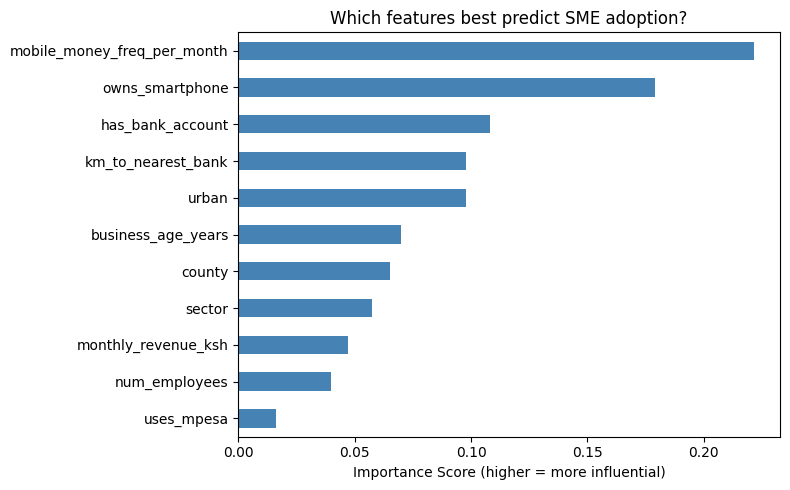

In [142]:
plt.figure(figsize=(8, 5))
feat_imp.plot(kind="barh", color="steelblue")
plt.title("Which features best predict SME adoption?")
plt.xlabel("Importance Score (higher = more influential)")
plt.tight_layout()
plt.show()

##  Phase 2 Results & What They Mean

### Model Accuracy Comparison
| Model | Accuracy |
|---|---|
| Logistic Regression | 86.00% |
| Random Forest | 87.75% ✅ Winner |

### What 87.75% Means in Business Terms
Our Random Forest model correctly predicts whether an SME will adopt
digital paybill payments **88 times out of every 100**.

For Absa and Airtel Money, this means:
- Instead of spending marketing budget on all SMEs blindly,
  they can now **focus only on the 88% they're most likely to convert**
- This directly reduces customer acquisition costs
- It makes every marketing shilling work harder

### Understanding the Scorecard
- **Precision 90%** — When the model flags an SME as a likely adopter,
  it is correct 9 out of 10 times
- **Recall 94%** — The model successfully identifies 94% of all SMEs
  that would have adopted anyway — very few slip through the net
- **F1-Score 92%** — The overall balance between precision and recall
  is excellent for a real-world business model

#Phase 3 — Live interactive dashboard running on a browser

In [143]:
#Install Streamlit
!pip install streamlit pyngrok -q

In [144]:
# writing app.py
app_code = """import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

st.set_page_config(
    page_title="SME Digital Payment Adoption Predictor",
    page_icon="🇰🇪",
    layout="wide"
)

st.title("🇰🇪 SME Digital Payment Adoption Predictor")
st.markdown(\"\"\"
**Built for Absa Bank Kenya & Airtel Money Kenya**
This tool predicts which SMEs are most likely to adopt
digital paybill payments via the Absa-Airtel partnership.
\"\"\")

st.divider()

@st.cache_resource
def train_model():
    np.random.seed(42)
    n = 2000

    counties = [
        "Nairobi", "Mombasa", "Kisumu", "Nakuru", "Eldoret",
        "Kiambu", "Machakos", "Meru", "Nyeri", "Kakamega",
        "Kisii", "Kilifi", "Garissa", "Kitui", "Bungoma",
        "Uasin Gishu", "Muranga", "Embu", "Kericho", "Migori"
    ]
    county_weights = [
        0.20, 0.08, 0.07, 0.07, 0.06, 0.06, 0.05,
        0.04, 0.04, 0.04, 0.04, 0.03, 0.03, 0.03,
        0.03, 0.03, 0.03, 0.02, 0.02, 0.02
    ]
    county_weights = [w / sum(county_weights) for w in county_weights]
    sectors = ["Retail", "Food & Beverage", "Transport", "Wholesale",
               "Salon/Barbershop", "Electronics", "Clothing", "Hardware"]

    df = pd.DataFrame({
        "county": np.random.choice(counties, n, p=county_weights),
        "sector": np.random.choice(sectors, n),
        "business_age_years": np.random.randint(1, 20, n),
        "monthly_revenue_ksh": np.random.choice(
            [5000, 15000, 35000, 75000, 150000, 300000],
            n, p=[0.15, 0.25, 0.30, 0.18, 0.08, 0.04]
        ),
        "uses_mpesa": np.random.choice([0, 1], n, p=[0.25, 0.75]),
        "has_bank_account": np.random.choice([0, 1], n, p=[0.40, 0.60]),
        "mobile_money_freq_per_month": np.random.randint(0, 60, n),
        "owns_smartphone": np.random.choice([0, 1], n, p=[0.35, 0.65]),
        "km_to_nearest_bank": np.random.exponential(scale=8, size=n).clip(0.5, 80),
        "num_employees": np.random.choice([1, 2, 3, 5, 10], n, p=[0.40, 0.25, 0.20, 0.10, 0.05]),
        "urban": np.random.choice([0, 1], n, p=[0.38, 0.62]),
    })

    adoption_score = (
        0.30 * (df["mobile_money_freq_per_month"] / 60) +
        0.20 * df["owns_smartphone"] +
        0.15 * df["has_bank_account"] +
        0.15 * df["urban"] +
        0.10 * (df["monthly_revenue_ksh"] / 300000) +
        0.05 * df["uses_mpesa"] +
        0.05 * (1 - df["km_to_nearest_bank"] / 80)
    )
    noise = np.random.normal(0, 0.08, n)
    df["will_adopt"] = ((adoption_score + noise).clip(0, 1) > 0.45).astype(int)

    le_county = LabelEncoder()
    le_sector = LabelEncoder()
    df["county_enc"] = le_county.fit_transform(df["county"])
    df["sector_enc"] = le_sector.fit_transform(df["sector"])

    features = ["county_enc", "sector_enc", "business_age_years",
                "monthly_revenue_ksh", "uses_mpesa", "has_bank_account",
                "mobile_money_freq_per_month", "owns_smartphone",
                "km_to_nearest_bank", "num_employees", "urban"]

    X = df[features]
    y = df["will_adopt"]

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)

    return rf, le_county, le_sector, df, features

rf, le_county, le_sector, df, features = train_model()

col1, col2 = st.columns([1, 1])

with col1:
    st.subheader("📋 Enter SME Details")

    county = st.selectbox("County", sorted([
        "Nairobi", "Mombasa", "Kisumu", "Nakuru", "Eldoret",
        "Kiambu", "Machakos", "Meru", "Nyeri", "Kakamega",
        "Kisii", "Kilifi", "Garissa", "Kitui", "Bungoma",
        "Uasin Gishu", "Muranga", "Embu", "Kericho", "Migori"
    ]))
    sector = st.selectbox("Business Sector", [
        "Retail", "Food & Beverage", "Transport", "Wholesale",
        "Salon/Barbershop", "Electronics", "Clothing", "Hardware"
    ])
    business_age = st.slider("Business Age (years)", 1, 20, 5)
    revenue = st.selectbox("Monthly Revenue (KSH)",
        [5000, 15000, 35000, 75000, 150000, 300000], index=2)
    uses_mpesa = st.radio("Does the SME use M-Pesa?", ["Yes", "No"])
    has_bank = st.radio("Does the SME have a bank account?", ["Yes", "No"])
    mm_freq = st.slider("Mobile Money Transactions per Month", 0, 60, 15)
    smartphone = st.radio("Does the owner own a smartphone?", ["Yes", "No"])
    km_bank = st.slider("Distance to Nearest Bank (km)", 1, 80, 10)
    employees = st.selectbox("Number of Employees", [1, 2, 3, 5, 10])
    urban = st.radio("Location Type", ["Urban", "Rural"])
    predict_btn = st.button("🔍 Predict Adoption Likelihood", type="primary")

with col2:
    st.subheader("🎯 Prediction Result")

    if predict_btn:
        county_enc = le_county.transform([county])[0]
        sector_enc = le_sector.transform([sector])[0]

        input_data = pd.DataFrame([{
            "county_enc": county_enc,
            "sector_enc": sector_enc,
            "business_age_years": business_age,
            "monthly_revenue_ksh": revenue,
            "uses_mpesa": 1 if uses_mpesa == "Yes" else 0,
            "has_bank_account": 1 if has_bank == "Yes" else 0,
            "mobile_money_freq_per_month": mm_freq,
            "owns_smartphone": 1 if smartphone == "Yes" else 0,
            "km_to_nearest_bank": km_bank,
            "num_employees": employees,
            "urban": 1 if urban == "Urban" else 0
        }])

        prob = rf.predict_proba(input_data)[0][1]
        prediction = "Will Adopt" if prob >= 0.5 else "Won't Adopt"

        st.metric(label="Adoption Probability", value=f"{prob:.0%}")

        if prob >= 0.7:
            st.success(f"✅ {prediction} — High priority SME. Target immediately.")
        elif prob >= 0.5:
            st.warning(f"⚠️ {prediction} — Medium priority. Nurture with incentives.")
        else:
            st.error(f"❌ {prediction} — Low priority. Focus resources elsewhere.")

        st.progress(float(prob))

        st.divider()
        st.markdown("#### 📊 What Drives This Prediction?")

        feat_imp = pd.Series(
            rf.feature_importances_,
            index=["County", "Sector", "Business Age", "Revenue",
                   "Uses M-Pesa", "Has Bank Account", "MM Frequency",
                   "Owns Smartphone", "Distance to Bank", "Employees", "Urban"]
        ).sort_values(ascending=True)

        fig, ax = plt.subplots(figsize=(6, 4))
        feat_imp.plot(kind="barh", ax=ax, color="steelblue")
        ax.set_title("Feature Importance")
        ax.set_xlabel("Importance Score")
        plt.tight_layout()
        st.pyplot(fig)

    else:
        st.info("👈 Fill in the SME details on the left and click Predict to see results.")

st.divider()
st.subheader("📍 Adoption Rate by County")
st.markdown("Which counties have the highest SME digital payment adoption potential?")

county_adoption = df.groupby("county")["will_adopt"].mean().sort_values(ascending=False)

fig2, ax2 = plt.subplots(figsize=(12, 4))
county_adoption.plot(kind="bar", ax=ax2, color="steelblue")
ax2.set_title("Predicted Adoption Rate by County")
ax2.set_ylabel("Adoption Rate")
ax2.set_xlabel("County")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
st.pyplot(fig2)

st.caption("Built by Ashley Nyaboke Kibwogo | SME Digital Payment Adoption Predictor | Absa & Airtel Kenya")
"""


In [150]:
import subprocess
import threading
import time
from pyngrok import ngrok

NGROK_TOKEN = "Add token here"

ngrok.set_auth_token(NGROK_TOKEN)

def run_streamlit():
    subprocess.run(["streamlit", "run", "app.py",
                   "--server.port", "8501",
                   "--server.headless", "true"])

thread = threading.Thread(target=run_streamlit)
thread.daemon = True
thread.start()

time.sleep(5)

public_url = ngrok.connect(8501)
print(f"\n🚀 Your dashboard is LIVE at: {public_url}")


🚀 Your dashboard is LIVE at: NgrokTunnel: "https://styling-uncapped-flaxseed.ngrok-free.dev" -> "http://localhost:8501"
